# OpenTouch Classification Training — Colab Setup
## 6.S985 Project — Direction B: Pre-Contact Intent Prediction

This notebook runs the three modality ablation experiments on Colab GPU.

**Before running**: Make sure you've selected a GPU runtime.
Runtime → Change runtime type → T4 GPU (free) or A100 (Colab Pro)

**Data**: Upload `preprocessed_data/` from your local machine to Google Drive first.

---
## 1. Check GPU

In [ ]:
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Go to Runtime -> Change runtime type -> GPU')

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


---
## 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Verify your data path — adjust if your Drive folder is named differently
import os
DRIVE_PROJECT = '/content/drive/MyDrive/6.S985/opentouch'
print('Files in project folder:')
print(os.listdir(DRIVE_PROJECT))

Mounted at /content/drive
Files in project folder:
['logs', 'train_dataset.zip', 'preprocessed_data.zip', 'checkpoints']


---
## 3. Clone OpenTouch and Install Dependencies

In [ ]:
# Clone the repo
!git clone https://github.com/OpenTouch-MIT/opentouch /content/opentouch
%cd /content/opentouch

# Install
!pip install -e . -q
!pip install datasets opencv-python -q

print('Install complete')

Cloning into '/content/opentouch'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 69 (delta 7), reused 69 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 3.93 MiB | 18.80 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/opentouch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for opentouch (pyproject.toml) ... done
Install complete


---
## 4. Copy Preprocessed Data from Drive

Upload the `preprocessed_data/` folder from your local machine to Google Drive first.
From your local machine:
```
# Zip and upload to Drive manually, or use rclone
cd /Users/cassandrahe/Documents/6.S985/opentouch
zip -r preprocessed_data.zip preprocessed_data/
```
Then upload `preprocessed_data.zip` to `My Drive/6.S985/`

In [ ]:
# Copy preprocessed data from Drive to Colab local storage (faster I/O)
!unzip -q {DRIVE_PROJECT}/preprocessed_data.zip -d /content/opentouch/

# Verify
!ls preprocessed_data/classification_peak/

data-00000-of-00008.arrow  data-00004-of-00008.arrow  dataset_info.json
data-00001-of-00008.arrow  data-00005-of-00008.arrow  label_info.json
data-00002-of-00008.arrow  data-00006-of-00008.arrow  state.json
data-00003-of-00008.arrow  data-00007-of-00008.arrow


---
## 5. HuggingFace Login (for DINOv3 if approved)

Skip this if using DINOv2 fallback.

In [ ]:
# Uncomment and run if DINOv3 access has been approved
from huggingface_hub import login
login()  # paste your HF token when prompted

---
## 6. Run Ablation Experiments

Three runs comparing modality combinations for grip type classification.
The gap between runs quantifies the value of each modality for Direction B.

### Run 1: Visual Only

In [ ]:
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual \
    --batch-size 64 --lr 3e-3 --epochs 30 \
    --report-to tensorboard \
    --name run1_visual_only_v5 \
    --device cuda \
    --workers 2 \
    --save-frequency 30 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-04-06,10:01:09 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x7945550cf5c0>
└ # D2 [2 B]
2026-04-06,10:03:15 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x79455467dc80>
└ # D2 [2 B]
2026-04-06,10:05:18 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-04-06,10:05:18 | INFO | Discovered num_classes from data: 28
2026-04-06,10:05:18 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--dinov3-vitb16-pretrain-lvd1689m/snapshots/5931719e67bbdb9737e363e781fb0c67687896bc/config.json
Model config DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 768,
  "image_

In [ ]:
!cp -r /content/opentouch/logs/run1_visual_only_v5 \
    /content/drive/MyDrive/6.S985/opentouch/logs/

In [ ]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run1_visual_only_v5/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda \
    --batch-size 8 \
    --workers 2

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['visual']  Epoch: 30
Classification split 'test': 263 samples from 263 clips.
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100% 211/211 [00:00<00:00, 1437.25it/s, Materializing param=norm.weight]
Loaded checkpoint from '/content/opentouch/logs/run1_visual_only_v5/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run1_visual_only_v5/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extension', 'Power Disk', 'Power Sp

### Run 2: Visual + Pose

In [ ]:
# Run 2: Visual + pose — Direction B core baseline (pre-contact only)
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual pose \
    --batch-size 64 --lr 3e-3 --epochs 30 \
    --report-to tensorboard \
    --name run2_visual_pose \
    --device cuda \
    --workers 2 \
    --save-frequency 30 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-04-06,13:25:55 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x79a57fda6b40>
└ # D2 [2 B]
2026-04-06,13:27:59 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x79a57e150d80>
└ # D2 [2 B]
2026-04-06,13:30:00 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-04-06,13:30:00 | INFO | Discovered num_classes from data: 28
2026-04-06,13:30:00 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--dinov3-vitb16-pretrain-lvd1689m/snapshots/5931719e67bbdb9737e363e781fb0c67687896bc/config.json
Model config DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 768,
  "image_

In [ ]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run2_visual_pose/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda \
    --batch-size 8 \
    --workers 2

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['visual', 'pose']  Epoch: 29
Classification split 'test': 263 samples from 263 clips.
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100% 211/211 [00:00<00:00, 668.14it/s, Materializing param=norm.weight]
Loaded checkpoint from '/content/opentouch/logs/run2_visual_pose/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run2_visual_pose/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extension', 'Power Disk', 'Power S

In [ ]:
!cp -r /content/opentouch/logs/run2_visual_pose \
    /content/drive/MyDrive/6.S985/opentouch/logs/

### Run 3: Visual + Pose + Tactile

In [ ]:
# Run 3: Visual + pose + tactile — upper bound with contact signal
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual pose tactile \
    --batch-size 64 --lr 3e-3 --epochs 30 \
    --report-to tensorboard \
    --name run3_visual_pose_tactile \
    --device cuda \
    --workers 2 \
    --save-frequency 30 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-04-06,18:24:39 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x79fa82bb6640>
└ # D2 [2 B]
2026-04-06,18:26:43 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x79fa803e5a80>
└ # D2 [2 B]
2026-04-06,18:28:47 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-04-06,18:28:47 | INFO | Discovered num_classes from data: 28
2026-04-06,18:28:47 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--dinov3-vitb16-pretrain-lvd1689m/snapshots/5931719e67bbdb9737e363e781fb0c67687896bc/config.json
Model config DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 768,
  "image_

In [ ]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run3_visual_pose_tactile/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda \
    --batch-size 8 \
    --workers 2

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['visual', 'pose', 'tactile']  Epoch: 29
Classification split 'test': 263 samples from 263 clips.
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100% 211/211 [00:00<00:00, 691.27it/s, Materializing param=norm.weight]
Loaded checkpoint from '/content/opentouch/logs/run3_visual_pose_tactile/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run3_visual_pose_tactile/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extensi

In [ ]:
!cp -r /content/opentouch/logs/run3_visual_pose_tactile \
    /content/drive/MyDrive/6.S985/opentouch/logs/

---
## 7. Collect Results

=== Results Summary ===
        Run              Modalities Test Accuracy Macro F1 Train Loss (ep.29)
          1                  Visual         31.9%    0.169              1.041
          2           Visual + Pose         30.0%    0.135              0.773
          3 Visual + Pose + Tactile         28.9%    0.144              0.758
4 (pending)               Pose only           TBD      TBD                TBD


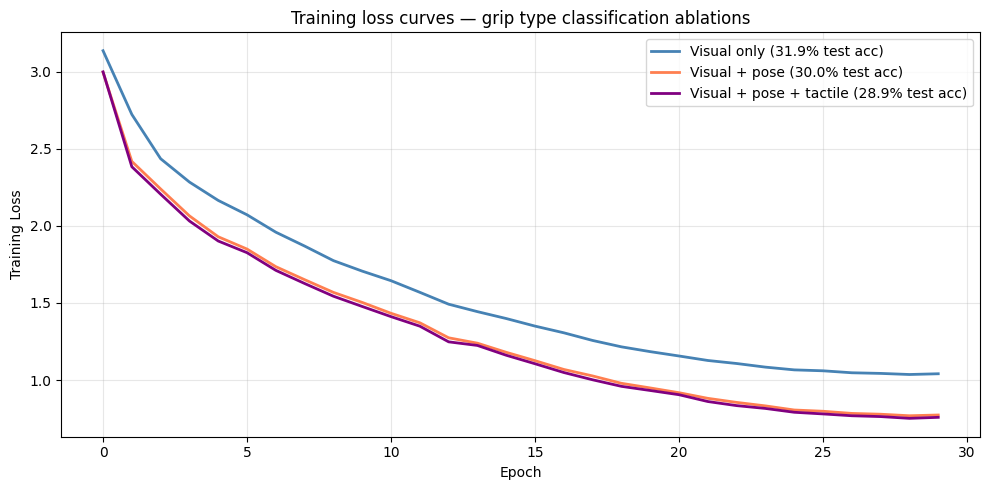

Saved to Drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = list(range(30))

# Training losses from all runs
run1_loss = [3.1355, 2.7223, 2.4351, 2.2837, 2.1646, 2.0714, 1.9586, 1.8686,
             1.7742, 1.7061, 1.6440, 1.5687, 1.4917, 1.4434, 1.3987, 1.3496,
             1.3062, 1.2565, 1.2152, 1.1840, 1.1558, 1.1267, 1.1071, 1.0836,
             1.0658, 1.0598, 1.0470, 1.0429, 1.0358, 1.0406]

run2_loss = [2.9956, 2.4177, 2.2390, 2.0644, 1.9289, 1.8492, 1.7350, 1.6506,
             1.5683, 1.5031, 1.4327, 1.3712, 1.2738, 1.2389, 1.1797, 1.1254,
             1.0685, 1.0264, 0.9787, 0.9486, 0.9177, 0.8812, 0.8549, 0.8322,
             0.8056, 0.7974, 0.7834, 0.7782, 0.7683, 0.7732]

run3_loss = [2.9984, 2.3831, 2.2050, 2.0312, 1.9014, 1.8257, 1.7112, 1.6259,
             1.5434, 1.4769, 1.4110, 1.3492, 1.2476, 1.2242, 1.1606, 1.1055,
             1.0486, 1.0015, 0.9590, 0.9321, 0.9047, 0.8605, 0.8340, 0.8157,
             0.7909, 0.7801, 0.7683, 0.7629, 0.7515, 0.7581]

# Results summary table
results = {
    'Run': ['1', '2', '3', '4 (pending)'],
    'Modalities': ['Visual', 'Visual + Pose', 'Visual + Pose + Tactile', 'Pose only'],
    'Test Accuracy': ['31.9%', '30.0%', '28.9%', 'TBD'],
    'Macro F1': ['0.169', '0.135', '0.144', 'TBD'],
    'Train Loss (ep.29)': ['1.041', '0.773', '0.758', 'TBD'],
}
import pandas as pd
df = pd.DataFrame(results)
print('=== Results Summary ===')
print(df.to_string(index=False))

# Training loss curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, run1_loss, label='Visual only (31.9% test acc)',
        color='steelblue', linewidth=2)
ax.plot(epochs, run2_loss, label='Visual + pose (30.0% test acc)',
        color='coral', linewidth=2)
ax.plot(epochs, run3_loss, label='Visual + pose + tactile (28.9% test acc)',
        color='purple', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training loss curves — grip type classification ablations')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save to Drive
!cp training_loss_curves.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/training_loss_curves.png
print('Saved to Drive')

# 8. Follow-up study
Given the above results, we can see that at 30 epochs, the frozen DINOv3 visual encoder provides a strong generalizable feature extractor, but the learned pose and tactile encoders overfit. The training loss gap (visual: 1.041 vs visual+pose+tactile: 0.758) shows the multimodal model fits training data better, but the test accuracy gap shows it generalizes worse. This motivates two things: longer training with regularization, and a more careful fusion strategy.

In [ ]:
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities pose \
    --batch-size 64 --lr 3e-3 --epochs 30 \
    --report-to tensorboard \
    --name run4_pose_only \
    --device cuda \
    --workers 2 \
    --save-frequency 30 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-04-06,23:31:06 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x799c0f44efc0>
└ # D2 [2 B]
2026-04-06,23:33:06 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x799c01724840>
└ # D2 [2 B]
2026-04-06,23:35:06 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-04-06,23:35:06 | INFO | Discovered num_classes from data: 28
2026-04-06,23:35:06 | INFO | Model:
2026-04-06,23:35:06 | INFO | ClassificationModel(
  (pose): PoseEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=63, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): GELU(approximate='none')
      (7): Dropout(p=0.1,

In [ ]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run4_pose_only/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda \
    --batch-size 8 \
    --workers 2

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['pose']  Epoch: 30
Classification split 'test': 263 samples from 263 clips.
Loaded checkpoint from '/content/opentouch/logs/run4_pose_only/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run4_pose_only/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extension', 'Power Disk', 'Power Sphere', 'Precision Disk', 'Precision Sphere', 'Prismatic 2 Finger', 'Prismatic 3 Finger', 'Prismatic 4 Finger', 'Ring', 'Small Diameter', 'Sphere 3 Finger', 'Sphere 4 Finger', 'Tip Pinch', 'Tripod', 'Tripod Variation', 'Ventral', 'Writing Tripod'])

  Accuracy   : 0.2167
  Macro F1   : 0.0432


In [ ]:
!cp -r /content/opentouch/logs/run4_pose_only \
    /content/drive/MyDrive/6.S985/opentouch/logs/

=== Results Summary ===
Run              Modalities Test Accuracy Macro F1 Train Loss (ep.29)
  1                  Visual         31.9%    0.169              1.041
  2           Visual + Pose         30.0%    0.135              0.773
  3 Visual + Pose + Tactile         28.9%    0.144              0.758
  4               Pose only         21.7%    0.043              2.208

Random chance baseline: 3.6% (1/28 classes)


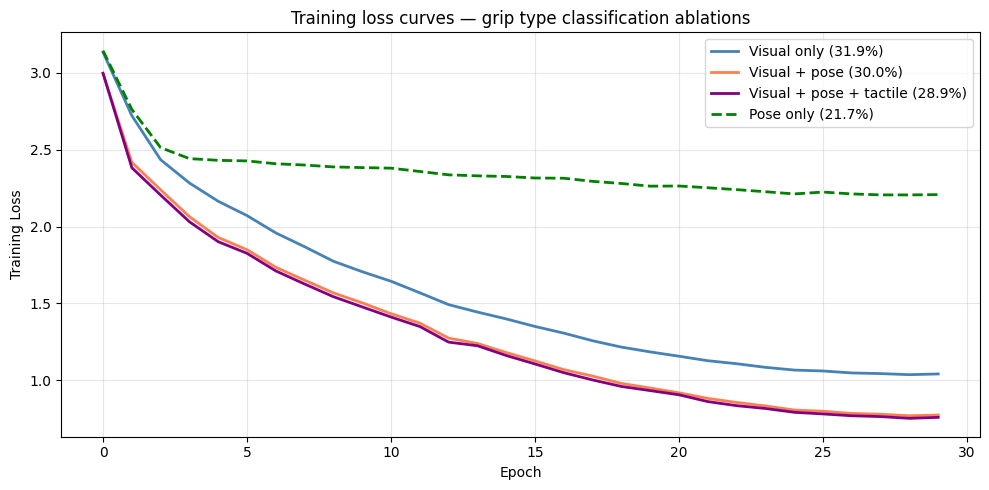

Saved to Drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

epochs = list(range(30))

run1_loss = [3.1355, 2.7223, 2.4351, 2.2837, 2.1646, 2.0714, 1.9586, 1.8686,
             1.7742, 1.7061, 1.6440, 1.5687, 1.4917, 1.4434, 1.3987, 1.3496,
             1.3062, 1.2565, 1.2152, 1.1840, 1.1558, 1.1267, 1.1071, 1.0836,
             1.0658, 1.0598, 1.0470, 1.0429, 1.0358, 1.0406]
run2_loss = [2.9956, 2.4177, 2.2390, 2.0644, 1.9289, 1.8492, 1.7350, 1.6506,
             1.5683, 1.5031, 1.4327, 1.3712, 1.2738, 1.2389, 1.1797, 1.1254,
             1.0685, 1.0264, 0.9787, 0.9486, 0.9177, 0.8812, 0.8549, 0.8322,
             0.8056, 0.7974, 0.7834, 0.7782, 0.7683, 0.7732]
run3_loss = [2.9984, 2.3831, 2.2050, 2.0312, 1.9014, 1.8257, 1.7112, 1.6259,
             1.5434, 1.4769, 1.4110, 1.3492, 1.2476, 1.2242, 1.1606, 1.1055,
             1.0486, 1.0015, 0.9590, 0.9321, 0.9047, 0.8605, 0.8340, 0.8157,
             0.7909, 0.7801, 0.7683, 0.7629, 0.7515, 0.7581]
run4_loss = [3.1449, 2.7629, 2.5139, 2.4423, 2.4314, 2.4274, 2.4090, 2.4006,
             2.3884, 2.3839, 2.3803, 2.3587, 2.3367, 2.3303, 2.3262, 2.3162,
             2.3147, 2.2944, 2.2805, 2.2631, 2.2640, 2.2527, 2.2405, 2.2268,
             2.2126, 2.2246, 2.2126, 2.2063, 2.2061, 2.2080]

# Results table
results = {
    'Run': ['1', '2', '3', '4'],
    'Modalities': ['Visual', 'Visual + Pose', 'Visual + Pose + Tactile', 'Pose only'],
    'Test Accuracy': ['31.9%', '30.0%', '28.9%', '21.7%'],
    'Macro F1': ['0.169', '0.135', '0.144', '0.043'],
    'Train Loss (ep.29)': ['1.041', '0.773', '0.758', '2.208'],
}
print('=== Results Summary ===')
print(pd.DataFrame(results).to_string(index=False))
print('\nRandom chance baseline: 3.6% (1/28 classes)')

# Training loss curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, run1_loss, label='Visual only (31.9%)',
        color='steelblue', linewidth=2)
ax.plot(epochs, run2_loss, label='Visual + pose (30.0%)',
        color='coral', linewidth=2)
ax.plot(epochs, run3_loss, label='Visual + pose + tactile (28.9%)',
        color='purple', linewidth=2)
ax.plot(epochs, run4_loss, label='Pose only (21.7%)',
        color='green', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training loss curves — grip type classification ablations')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save everything to Drive
!cp training_loss_curves.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/training_loss_curves.png
print('Saved to Drive')

## Run 1, 60 epochs

Another follow-up if there's time

In [ ]:
# 60-epoch visual run
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual \
    --batch-size 64 --lr 3e-3 --epochs 60 \
    --report-to tensorboard \
    --name run1_visual_60ep_v2 \
    --device cuda \
    --workers 2 \
    --save-frequency 60 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-04-07,10:49:03 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x7f4726321dc0>
└ # D2 [2 B]
2026-04-07,10:51:08 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x7f47240fcac0>
└ # D2 [2 B]
2026-04-07,10:53:09 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-04-07,10:53:09 | INFO | Discovered num_classes from data: 28
2026-04-07,10:53:09 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
2026-04-07,10:53:09 | INFO | HTTP Request: GET https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
config.json: 100% 744/744 [00:00<00:00, 3.76MB/s]
2026-04-07,10:53:09 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
loading configuration file config.json from cache at /ro

In [ ]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run1_visual_60ep_v2/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda \
    --batch-size 8 \
    --workers 2

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['visual']  Epoch: 59
Classification split 'test': 263 samples from 263 clips.
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100% 211/211 [00:00<00:00, 688.40it/s, Materializing param=norm.weight]
Loaded checkpoint from '/content/opentouch/logs/run1_visual_60ep_v2/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run1_visual_60ep_v2/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extension', 'Power Disk', 'Power Sph

In [ ]:
!cp -r /content/opentouch/logs/run1_visual_60ep_v2 \
    /content/drive/MyDrive/6.S985/opentouch/logs/

Visual-only run comparisons

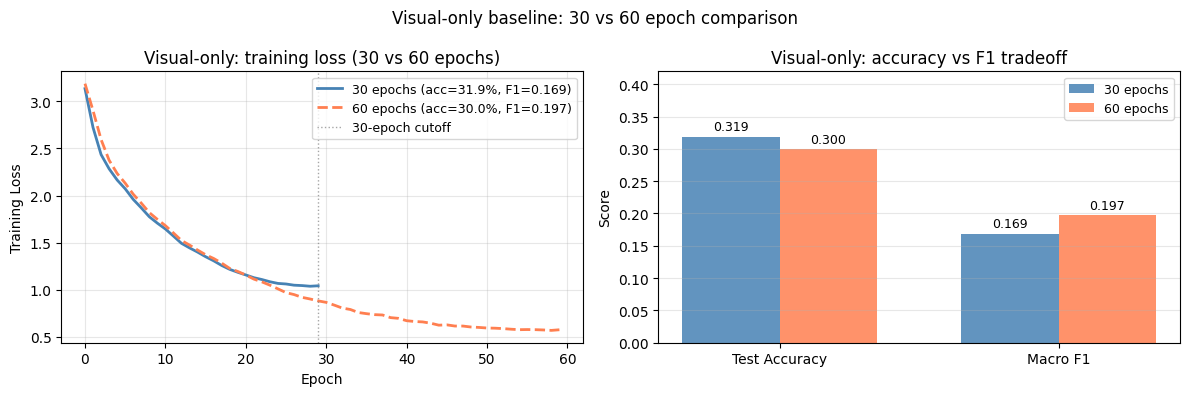

Saved


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 30-epoch run (Run 1)
run1_30ep = [3.1355, 2.7223, 2.4351, 2.2837, 2.1646, 2.0714, 1.9586, 1.8686,
             1.7742, 1.7061, 1.6440, 1.5687, 1.4917, 1.4434, 1.3987, 1.3496,
             1.3062, 1.2565, 1.2152, 1.1840, 1.1558, 1.1267, 1.1071, 1.0836,
             1.0658, 1.0598, 1.0470, 1.0429, 1.0358, 1.0406]

# 60-epoch run
run1_60ep = [3.1884, 2.9021, 2.5948, 2.3748, 2.2341, 2.1309, 2.0135, 1.9188,
             1.8181, 1.7466, 1.6797, 1.6015, 1.5218, 1.4734, 1.4203, 1.3706,
             1.3309, 1.2814, 1.2249, 1.1928, 1.1550, 1.1117, 1.0822, 1.0471,
             1.0077, 0.9680, 0.9472, 0.9177, 0.9002, 0.8802, 0.8644, 0.8352,
             0.8038, 0.7888, 0.7566, 0.7444, 0.7341, 0.7304, 0.7023, 0.6944,
             0.6695, 0.6611, 0.6567, 0.6429, 0.6221, 0.6255, 0.6129, 0.6128,
             0.6025, 0.5981, 0.5919, 0.5901, 0.5856, 0.5792, 0.5742, 0.5756,
             0.5743, 0.5713, 0.5667, 0.5733]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: training loss comparison
axes[0].plot(range(30), run1_30ep, label='30 epochs (acc=31.9%, F1=0.169)',
             color='steelblue', linewidth=2)
axes[0].plot(range(60), run1_60ep, label='60 epochs (acc=30.0%, F1=0.197)',
             color='coral', linewidth=2, linestyle='--')
axes[0].axvline(29, color='gray', linestyle=':', linewidth=1, alpha=0.7,
                label='30-epoch cutoff')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Visual-only: training loss (30 vs 60 epochs)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: bar chart comparing test accuracy and macro F1
metrics = ['Test Accuracy', 'Macro F1']
vals_30 = [0.319, 0.169]
vals_60 = [0.300, 0.197]
x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, vals_30, width, label='30 epochs',
                     color='steelblue', alpha=0.85)
bars2 = axes[1].bar(x + width/2, vals_60, width, label='60 epochs',
                     color='coral', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score')
axes[1].set_title('Visual-only: accuracy vs F1 tradeoff')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 0.42)
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Visual-only baseline: 30 vs 60 epoch comparison', fontsize=12)
plt.tight_layout()
plt.savefig('visual_only_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

!cp visual_only_comparison.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/visual_only_comparison.png
print('Saved')

# Retrieval Baseline (v2t)

In [ ]:
!unzip -o -q /content/drive/MyDrive/6.S985/opentouch/train_dataset.zip \
    -d /content/opentouch/preprocessed_data/

In [ ]:
!python build_retrieval_data.py \
    --input-dir preprocessed_data/classification_peak \
    --output-dir preprocessed_data/train_dataset

Traceback (most recent call last):
  File "/content/opentouch/build_retrieval_data.py", line 240, in <module>
    main()
  File "/content/opentouch/build_retrieval_data.py", line 199, in main
    file_paths = list_hdf5_files(args.input_dir)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/opentouch/build_retrieval_data.py", line 63, in list_hdf5_files
    raise FileNotFoundError(f"No .hdf5 files found in directory: {input_dir}")
FileNotFoundError: No .hdf5 files found in directory: preprocessed_data/classification_peak


In [ ]:
!ls /content/drive/MyDrive/6.S985/opentouch/
!ls /content/opentouch/scripts/

logs  preprocessed_data.zip  train_dataset.zip
download_data.sh    extract_demo.sh	       train_debug.sh
eval_classifier.sh  train_classifier_debug.sh  train_multigpu.sh
eval.sh		    train_classifier.sh        train.sh


In [ ]:
!cd /content/opentouch && bash scripts/download_data.sh

Downloading...
From (original): https://drive.google.com/uc?id=1EjMOzs45devBo0TqhuhZTT_Ll7HZ1lrW
From (redirected): https://drive.google.com/uc?id=1EjMOzs45devBo0TqhuhZTT_Ll7HZ1lrW&confirm=t&uuid=b611d93c-d65d-485b-8512-d9b15da4eff9
To: /content/opentouch/data/office_csail_p2.hdf5
100% 587M/587M [00:08<00:00, 70.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1fAmmieSr0yFm7ldhW7Smld7jUxBCw8fu
From (redirected): https://drive.google.com/uc?id=1fAmmieSr0yFm7ldhW7Smld7jUxBCw8fu&confirm=t&uuid=4b109451-0dbd-40de-9970-d6f1454f5912
To: /content/opentouch/data/office_ml_p1.hdf5
100% 1.72G/1.72G [00:18<00:00, 92.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1cUhgYbredkIRswanUiM5uDixiFLq4WCC
From (redirected): https://drive.google.com/uc?id=1cUhgYbredkIRswanUiM5uDixiFLq4WCC&confirm=t&uuid=5ab05291-2ed7-4eb5-bc75-505c8db85b31
To: /content/opentouch/data/office_ml_p2.hdf5
100% 1.54G/1.54G [00:26<00:00, 57.6MB/s]
Downloading...
From (original): https:/

In [ ]:
!python /content/opentouch/build_retrieval_data.py \
    --input-dir /content/opentouch/data \
    --output-dir /content/opentouch/preprocessed_data/train_dataset

Streaming output truncated to the last 5000 lines.
Generating train split: 302917 examples [2:40:00, 37.11 examples/s]
Generating train split: 302921 examples [2:40:00, 36.16 examples/s]
Generating train split: 302925 examples [2:40:00, 36.73 examples/s]
Generating train split: 302929 examples [2:40:00, 37.34 examples/s]
Generating train split: 302933 examples [2:40:00, 37.47 examples/s]
Generating train split: 302937 examples [2:40:01, 36.51 examples/s]
Generating train split: 302941 examples [2:40:01, 37.12 examples/s]
Generating train split: 302945 examples [2:40:01, 35.95 examples/s]
Generating train split: 302949 examples [2:40:01, 36.55 examples/s]
Generating train split: 302954 examples [2:40:01, 37.64 examples/s]
Generating train split: 302958 examples [2:40:01, 37.21 examples/s]
Generating train split: 302962 examples [2:40:01, 37.07 examples/s]
Generating train split: 302966 examples [2:40:01, 35.69 examples/s]
Extracting frames:  93% 302967/327030 [2:40:01<11:14, 35.70frame/

In [ ]:
!find /content/opentouch -name "*Retrieval*"

/content/opentouch/src/opentouch/model_configs/OpenTouch-DINOv3-B16-Retrieval.json


In [ ]:
import os, glob

# Find the misnamed file
files = glob.glob('/content/opentouch/src/opentouch/model_configs/OpenTouch-DINOv3-B16-Retrieval copy.json', recursive=True)
print(files)
os.rename(
    '/content/opentouch/src/opentouch/model_configs/OpenTouch-DINOv3-B16-Retrieval',
    '/content/opentouch/src/opentouch/model_configs/OpenTouch-DINOv3-B16-Retrieval.json'
)

[]


In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

!CUDA_VISIBLE_DEVICES=0 python -m opentouch_train.main \
    --train-data preprocessed_data/train_dataset \
    --model OpenTouch-DINOv3-B16-Retrieval \
    --task-type v2t \
    --batch-size 32 \
    --lr 1e-4 \
    --epochs 300 \
    --precision amp \
    --workers 2 \
    --sequence-length 20 \
    --report-to tensorboard \
    --name retrieval_v2t_v5

2026-04-08,19:29:17 | INFO | Running with a single process. Device cuda.
2026-04-08,19:29:17 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--dinov3-vitb16-pretrain-lvd1689m/snapshots/5931719e67bbdb9737e363e781fb0c67687896bc/config.json
Model config DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "key_bias": false,
  "layer_norm_eps": 1e-05,
  "layerscale_value": 1.0,
  "mlp_bias": true,
  "model_type": "dinov3_vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "num_register_tokens": 4,
  "out_features": [
    "stage12"
  ],
  "

In [ ]:
# Before cancelling, save the checkpoint
!cp -r ./logs/retrieval_v2t_v5 \
    /content/drive/MyDrive/6.S985/opentouch/logs/

# Gated Fusion Experiments


## Software Patches

In [ ]:
# Patch 1: Add --fusion-method argument to classification_params.py
old_arg = '''    parser.add_argument(
        "--label-smoothing",
        type=float,
        default=0.0,
        help="Label smoothing factor for cross-entropy loss.",
    )'''

new_arg = '''    parser.add_argument(
        "--fusion-method",
        type=str,
        default="concat",
        choices=["concat", "gated"],
        help="Fusion method for combining modality embeddings.",
    )
    parser.add_argument(
        "--label-smoothing",
        type=float,
        default=0.0,
        help="Label smoothing factor for cross-entropy loss.",
    )'''

filepath = '/content/opentouch/src/opentouch_train/classification_params.py'
with open(filepath, 'r') as f:
    content = f.read()
content = content.replace(old_arg, new_arg)
with open(filepath, 'w') as f:
    f.write(content)
print("Patch 1 applied.")
!grep -n "fusion" /content/opentouch/src/opentouch_train/classification_params.py

Patch 1 applied.
76:        "--fusion-method",
83:        "--fusion-method",


In [ ]:
old_call = '''    model = create_classification_model(
        args.model,
        num_classes=num_classes,
        pretrained=args.pretrained,
        precision=args.precision,
        device=device,
        cache_dir=args.cache_dir,
        enabled_modalities=args.enabled_modalities,
    )'''

new_call = '''    model = create_classification_model(
        args.model,
        num_classes=num_classes,
        pretrained=args.pretrained,
        precision=args.precision,
        device=device,
        cache_dir=args.cache_dir,
        enabled_modalities=args.enabled_modalities,
        fusion_method=args.fusion_method,
    )'''

filepath = '/content/opentouch/src/opentouch_train/classification_main.py'
with open(filepath, 'r') as f:
    content = f.read()
content = content.replace(old_call, new_call)
with open(filepath, 'w') as f:
    f.write(content)
print("Patch 2 applied.")
!grep -n "fusion" /content/opentouch/src/opentouch_train/classification_main.py

Patch 2 applied.
185:        fusion_method=args.fusion_method,


In [ ]:
gated_class = '''

class GatedFusion(nn.Module):
    """Dynamically weights two modality embeddings via a learned gate."""
    def __init__(self, embed_dim: int):
        super().__init__()
        self.gate = nn.Linear(embed_dim * 2, embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        half = x.shape[-1] // 2
        z1, z2 = x[..., :half], x[..., half:]
        g = torch.sigmoid(self.gate(x))
        return g * z1 + (1 - g) * z2

'''

old_fusion = '''        elif self.fusion_method == "concat":
            concat_dim = self.embed_dim * n_modalities
            self.fusion = nn.Linear(concat_dim, self.embed_dim)
            self._feature_dim = self.embed_dim
        else:
            raise ValueError("Invalid model configuration.")'''

new_fusion = '''        elif self.fusion_method == "concat":
            concat_dim = self.embed_dim * n_modalities
            self.fusion = nn.Linear(concat_dim, self.embed_dim)
            self._feature_dim = self.embed_dim
        elif self.fusion_method == "gated":
            if n_modalities != 2:
                raise ValueError("Gated fusion only supports exactly 2 modalities.")
            self.fusion = GatedFusion(self.embed_dim)
            self._feature_dim = self.embed_dim
        else:
            raise ValueError("Invalid model configuration.")'''

filepath = '/content/opentouch/src/opentouch/classification.py'
with open(filepath, 'r') as f:
    content = f.read()

# Insert GatedFusion class before the ClassificationModel class definition
content = content.replace(
    'class ClassificationModel',
    gated_class + 'class ClassificationModel',
    1
)

# Add gated branch to _init_fusion
content = content.replace(old_fusion, new_fusion)

with open(filepath, 'w') as f:
    f.write(content)

print("Patch reapplied. Verifying...")
!grep -n "GatedFusion\|gated" /content/opentouch/src/opentouch/classification.py

Patch reapplied. Verifying...
19:class GatedFusion(nn.Module):
33:class GatedFusion(nn.Module):
121:        elif self.fusion_method == "gated":
124:            self.fusion = GatedFusion(self.embed_dim)


In [ ]:
!grep -n "gated\|GatedFusion\|fusion_method" \
    /content/opentouch/src/opentouch/classification.py \
    /content/opentouch/src/opentouch_train/classification_params.py \
    /content/opentouch/src/opentouch_train/classification_main.py

/content/opentouch/src/opentouch/classification.py:19:class GatedFusion(nn.Module):
/content/opentouch/src/opentouch/classification.py:33:class GatedFusion(nn.Module):
/content/opentouch/src/opentouch/classification.py:57:        fusion_method: str = "concat",
/content/opentouch/src/opentouch/classification.py:62:        self.fusion_method = fusion_method
/content/opentouch/src/opentouch/classification.py:117:        elif self.fusion_method == "concat":
/content/opentouch/src/opentouch/classification.py:121:        elif self.fusion_method == "gated":
/content/opentouch/src/opentouch/classification.py:124:            self.fusion = GatedFusion(self.embed_dim)
/content/opentouch/src/opentouch_train/classification_params.py:79:        choices=["concat", "gated"],
/content/opentouch/src/opentouch_train/classification_params.py:86:        choices=["concat", "gated"],
/content/opentouch/src/opentouch_train/classification_main.py:185:        fusion_method=args.fusion_method,


## Runs

In [ ]:
# Run 5: Gated fusion, visual + pose, 60 epochs
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip \
    --modalities visual pose \
    --fusion-method gated \
    --batch-size 64 \
    --lr 3e-3 \
    --epochs 60 \
    --report-to tensorboard \
    --name run5_gated_fusion_60ep \
    --device cuda \
    --workers 4 \
    --save-frequency 60 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-05-10,22:50:16 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x7ece75016d80>
└ # D2 [2 B]
2026-05-10,22:52:06 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x7ece746c14c0>
└ # D2 [2 B]
2026-05-10,22:53:57 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-05-10,22:53:57 | INFO | Discovered num_classes from data: 28
2026-05-10,22:53:57 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
2026-05-10,22:53:57 | INFO | HTTP Request: GET https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
config.json: 100% 744/744 [00:00<00:00, 3.26MB/s]
2026-05-10,22:53:57 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
loading configuration file config.json from cache at /ro

In [ ]:
# Run 2 extended: Visual + pose, 60 epochs (concat baseline for comparison)
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip \
    --modalities visual pose \
    --fusion-method concat \
    --batch-size 64 \
    --lr 3e-3 \
    --epochs 60 \
    --report-to tensorboard \
    --name run2_visual_pose_60ep \
    --device cuda \
    --workers 4 \
    --save-frequency 60 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-05-10,18:00:10 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x7d18eabaf5c0>
└ # D2 [2 B]
2026-05-10,18:02:04 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x7d1900078d80>
└ # D2 [2 B]
2026-05-10,18:03:56 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-05-10,18:03:56 | INFO | Discovered num_classes from data: 28
2026-05-10,18:03:56 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--dinov3-vitb16-pretrain-lvd1689m/snapshots/5931719e67bbdb9737e363e781fb0c67687896bc/config.json
Model config DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 768,
  "image_

In [ ]:
import os

# Fix the config name
os.rename(
    '/content/opentouch/src/opentouch/model_configs/OpenTouch-DINOv3-B16-Retrieval copy.json',
    '/content/opentouch/src/opentouch/model_configs/OpenTouch-DINOv3-B16-Retrieval.json'
)

# Verify
!ls /content/opentouch/src/opentouch/model_configs/

OpenTouch-DINOv3-B16-Classify.json  OpenTouch-DINOv3-B16-Retrieval.json
OpenTouch-DINOv3-B16.json


In [ ]:
# Unzip retrieval dataset from Drive
!unzip -o -q /content/drive/MyDrive/6.S985/opentouch/train_dataset.zip \
    -d /content/opentouch/preprocessed_data/

# Verify
!ls /content/opentouch/preprocessed_data/train_dataset/

ls: cannot access '/content/opentouch/preprocessed_data/train_dataset/': No such file or directory


In [ ]:
# Check what's inside the nested folder
!ls /content/opentouch/preprocessed_data/preprocessed_data/

# Move train_dataset up one level
!mv /content/opentouch/preprocessed_data/preprocessed_data/train_dataset \
    /content/opentouch/preprocessed_data/train_dataset

# Verify
!ls /content/opentouch/preprocessed_data/
!ls /content/opentouch/preprocessed_data/train_dataset/ | head -5

train_dataset
classification_peak  preprocessed_data	train_dataset
data-00000-of-00055.arrow
data-00001-of-00055.arrow
data-00002-of-00055.arrow
data-00003-of-00055.arrow
data-00004-of-00055.arrow


#### Retrieval Baseline

In [ ]:
!CUDA_VISIBLE_DEVICES=0 python -m opentouch_train.main \
    --train-data /content/opentouch/preprocessed_data/train_dataset \
    --model OpenTouch-DINOv3-B16-Retrieval \
    --task-type v2t \
    --batch-size 64 \
    --lr 1e-4 \
    --epochs 100 \
    --precision amp \
    --workers 4 \
    --sequence-length 20 \
    --report-to tensorboard \
    --name retrieval_v2t_100ep_v5 \
    --logs ./logs/

2026-05-17,19:30:02 | INFO | Running with a single process. Device cuda.
2026-05-17,19:30:03 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--dinov3-vitb16-pretrain-lvd1689m/snapshots/5931719e67bbdb9737e363e781fb0c67687896bc/config.json
Model config DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "key_bias": false,
  "layer_norm_eps": 1e-05,
  "layerscale_value": 1.0,
  "mlp_bias": true,
  "model_type": "dinov3_vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "num_register_tokens": 4,
  "out_features": [
    "stage12"
  ],
  "

In [ ]:
!cp -r ./logs/retrieval_v2t_100ep_v5 \
    /content/drive/MyDrive/6.S985/opentouch/logs/

In [ ]:
os.makedirs('/content/drive/MyDrive/6.S985/opentouch/checkpoints/encoders', exist_ok=True)

# Best visual-only (60 epochs)
export_encoders(
    '/content/drive/MyDrive/6.S985/opentouch/logs/run1_visual_60ep_v2/checkpoints/epoch_latest.pt',
    '/content/drive/MyDrive/6.S985/opentouch/checkpoints/encoders/visual_only_60ep.pt'
)

# Best gated fusion visual+pose (60 epochs)
export_encoders(
    '/content/drive/MyDrive/6.S985/opentouch/logs/run5_gated_fusion_60ep_v2/checkpoints/epoch_latest.pt',
    '/content/drive/MyDrive/6.S985/opentouch/checkpoints/encoders/visual_pose_gated_60ep.pt'
)

# Per-Class Qualitative Analysis

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Overall accuracy: 0.300


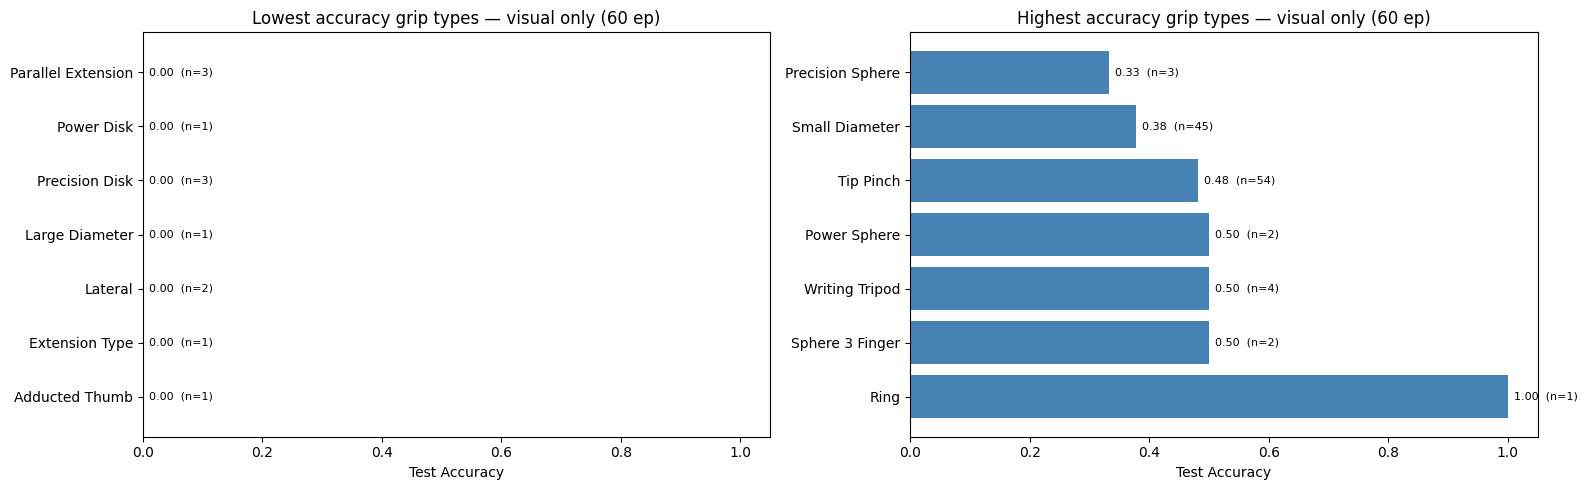

Saved per_class_accuracy.png


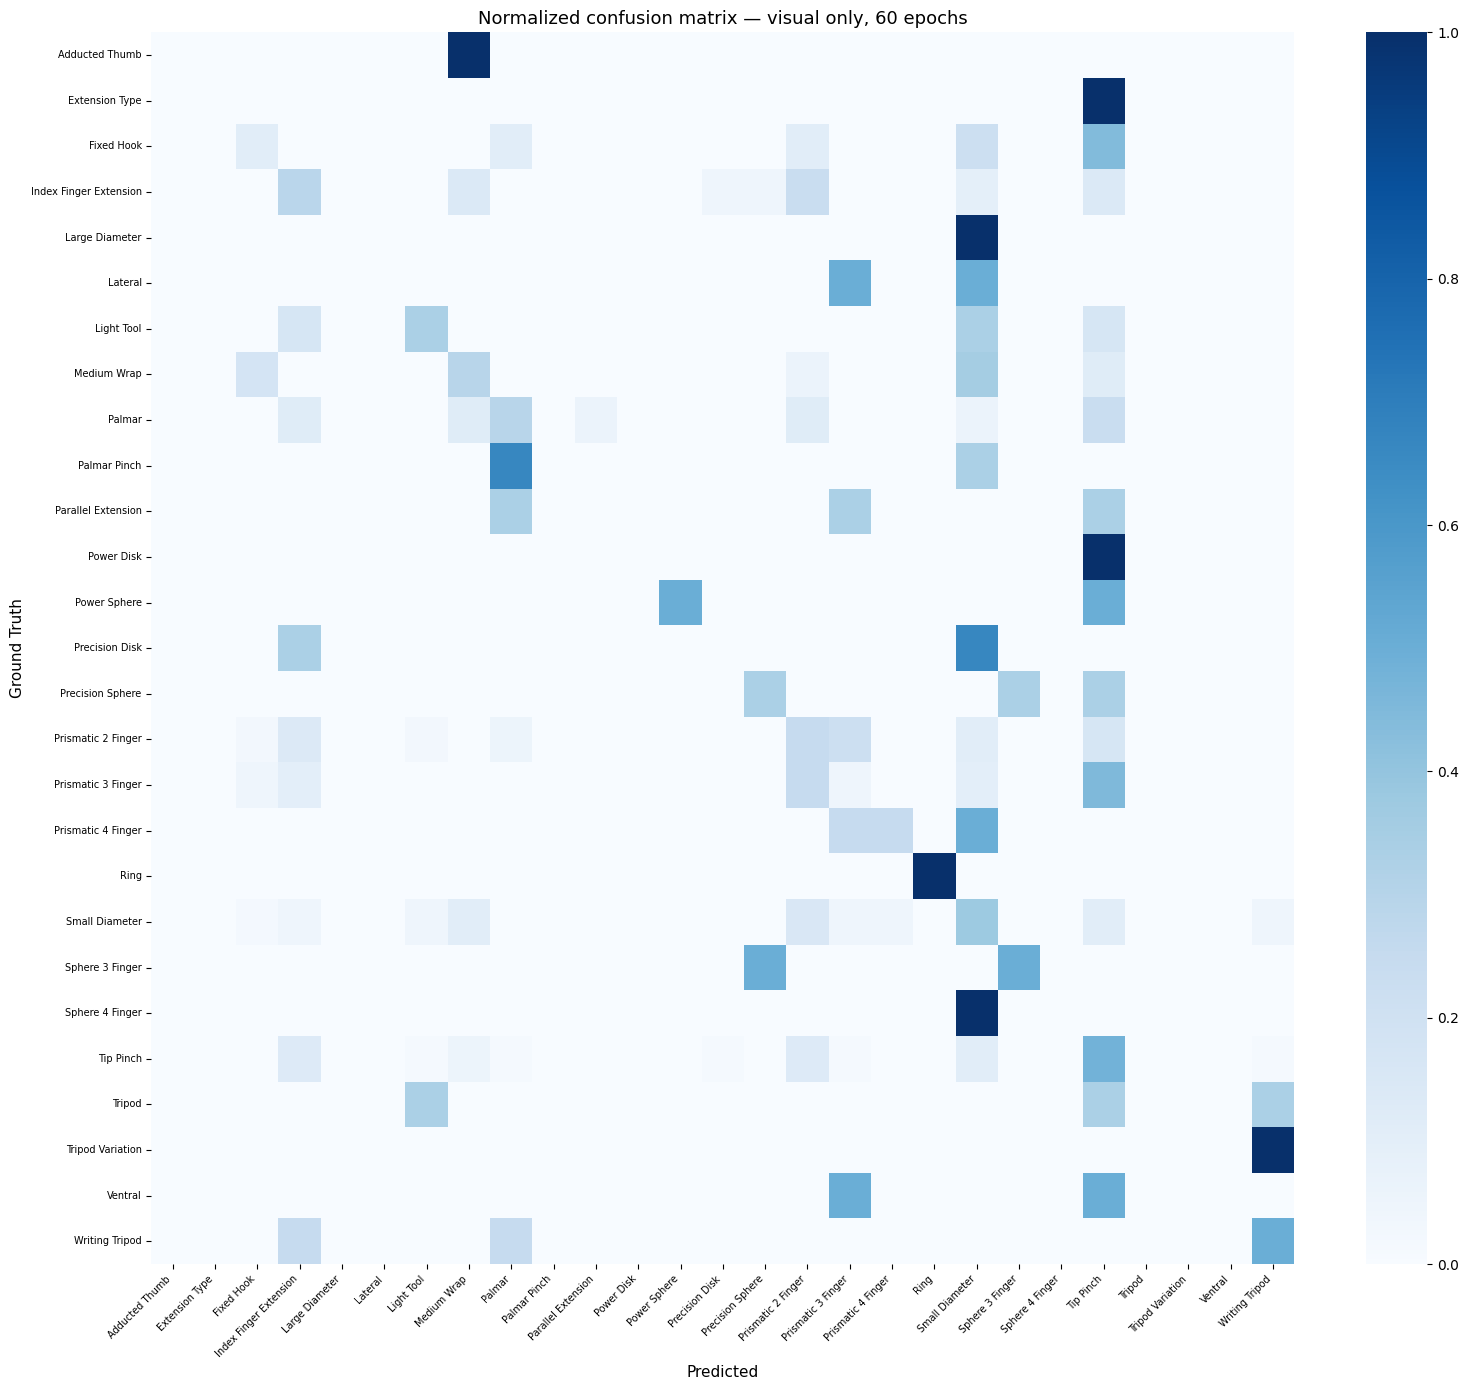

Saved confusion_matrix.png
Saved to Drive


In [ ]:
# ── Load model ────────────────────────────────────────────────────────────────
checkpoint = torch.load(
    '/content/drive/MyDrive/6.S985/opentouch/logs/run1_visual_60ep_v2/checkpoints/epoch_latest.pt',
    map_location='cpu'
)

model = create_classification_model(
    'OpenTouch-DINOv3-B16-Classify',
    num_classes=28,
    enabled_modalities=['visual'],
    device='cuda',
)
model.load_state_dict(checkpoint['state_dict'])
model.eval()
model = model.cuda()

# ── Run inference ─────────────────────────────────────────────────────────────
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=2)
class_names = dataset.classes

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in dataloader:
        rgb = batch['rgb_images'].cuda()
        labels = batch['label'].cuda()
        logits = model(rgb_images=rgb)  # (B, 28) tensor directly
        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print(f"Overall accuracy: {(all_preds == all_labels).mean():.3f}")

# ── Per-class accuracy ────────────────────────────────────────────────────────
per_class_acc = []
per_class_n   = []
for i in range(28):
    mask = all_labels == i
    n = mask.sum()
    acc = (all_preds[mask] == all_labels[mask]).mean() if n > 0 else 0.0
    per_class_acc.append(float(acc))
    per_class_n.append(int(n))

per_class_acc = np.array(per_class_acc)
per_class_n   = np.array(per_class_n)

# ── Top/bottom bar chart ──────────────────────────────────────────────────────
# Only include classes that appear in test set
present = np.where(per_class_n > 0)[0]
present_acc   = per_class_acc[present]
present_names = [class_names[i] for i in present]
present_n     = per_class_n[present]

sorted_idx    = np.argsort(present_acc)
n_show        = 7  # top and bottom 7

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bottom 7
bot_idx = sorted_idx[:n_show]
axes[0].barh(
    [present_names[i] for i in bot_idx],
    present_acc[bot_idx],
    color='salmon'
)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Lowest accuracy grip types — visual only (60 ep)')
axes[0].set_xlim(0, 1.05)
for i, idx in enumerate(bot_idx):
    axes[0].text(
        present_acc[idx] + 0.01, i,
        f'{present_acc[idx]:.2f}  (n={present_n[idx]})',
        va='center', fontsize=8
    )

# Top 7
top_idx = sorted_idx[-n_show:][::-1]
axes[1].barh(
    [present_names[i] for i in top_idx],
    present_acc[top_idx],
    color='steelblue'
)
axes[1].set_xlabel('Test Accuracy')
axes[1].set_title('Highest accuracy grip types — visual only (60 ep)')
axes[1].set_xlim(0, 1.05)
for i, idx in enumerate(top_idx):
    axes[1].text(
        present_acc[idx] + 0.01, i,
        f'{present_acc[idx]:.2f}  (n={present_n[idx]})',
        va='center', fontsize=8
    )

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved per_class_accuracy.png")

# ── Confusion matrix ──────────────────────────────────────────────────────────
present_all   = sorted(set(all_labels.tolist()) | set(all_preds.tolist()))
present_names_all = [class_names[i] for i in present_all]

cm      = confusion_matrix(all_labels, all_preds, labels=present_all)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_norm,
    xticklabels=present_names_all,
    yticklabels=present_names_all,
    annot=False,
    cmap='Blues',
    ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Ground Truth', fontsize=11)
ax.set_title('Normalized confusion matrix — visual only, 60 epochs', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion_matrix.png")

# ── Save to Drive ─────────────────────────────────────────────────────────────
!cp per_class_accuracy.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/per_class_accuracy.png
!cp confusion_matrix.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/confusion_matrix.png
print("Saved to Drive")

In [ ]:
!cp per_class_accuracy.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/per_class_accuracy.png
!cp confusion_matrix.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/confusion_matrix.png

#### Gated Fusion Checkpoint PCQA

Gated fusion accuracy: 0.312


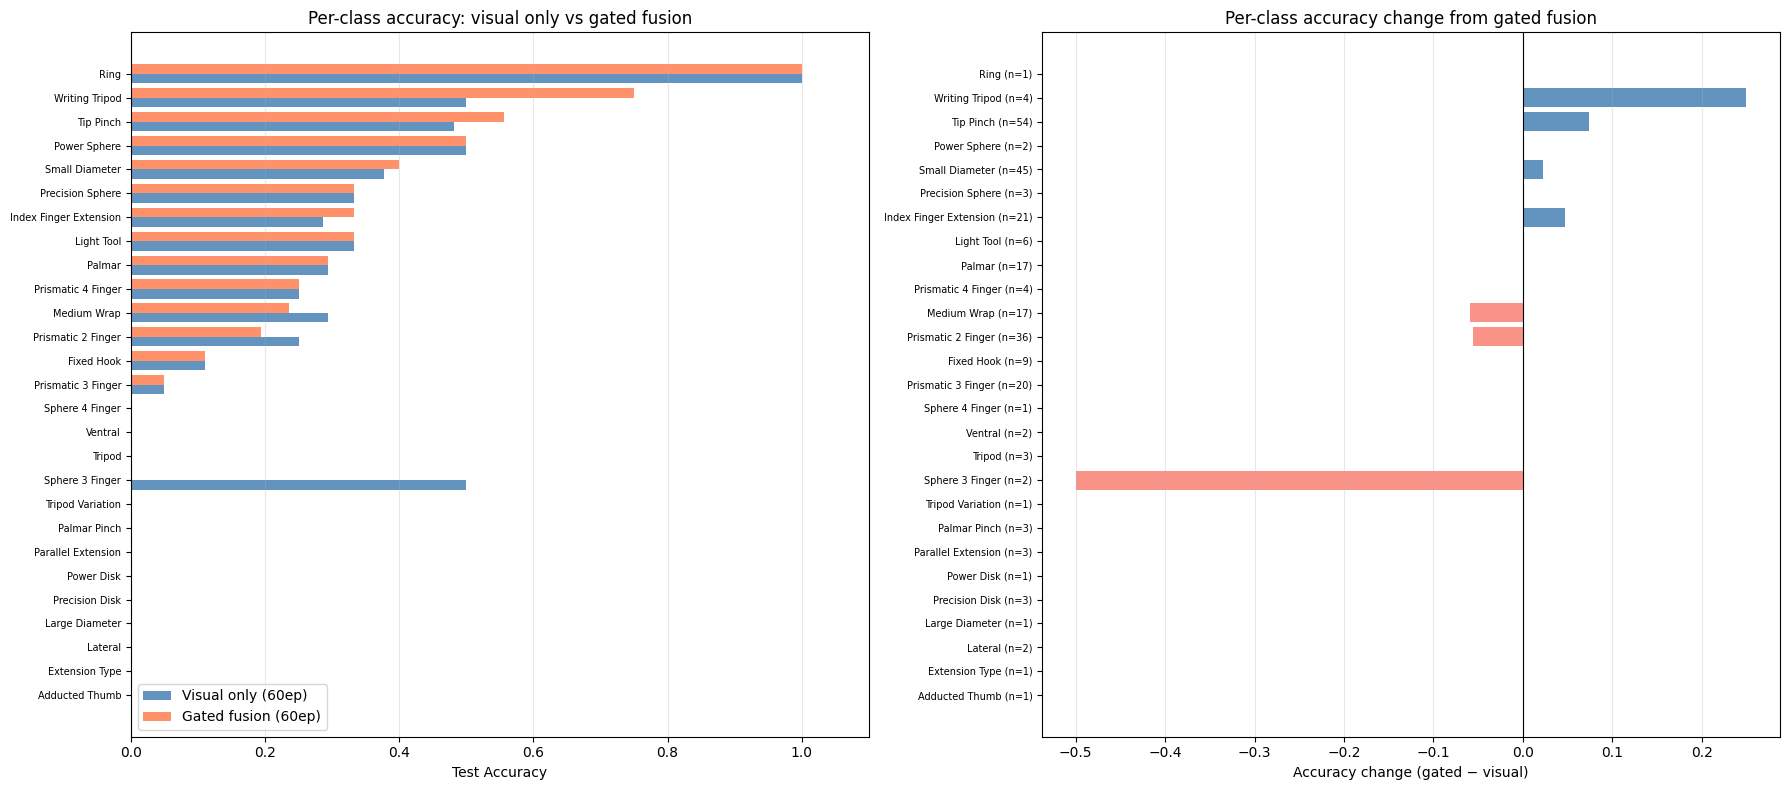

Saved per_class_comparison.png

Biggest improvements (gated > visual):
  Writing Tripod             0.50 → 0.75  (n=4)
  Tip Pinch                  0.48 → 0.56  (n=54)
  Index Finger Extension     0.29 → 0.33  (n=21)
  Small Diameter             0.38 → 0.40  (n=45)
  Tripod Variation           0.00 → 0.00  (n=1)

Biggest regressions (visual > gated):
  Sphere 3 Finger            0.50 → 0.00  (n=2)
  Medium Wrap                0.29 → 0.24  (n=17)
  Prismatic 2 Finger         0.25 → 0.19  (n=36)
  Fixed Hook                 0.11 → 0.11  (n=9)
  Lateral                    0.00 → 0.00  (n=2)


In [ ]:
# ── Inference: Gated Fusion ───────────────────────────────────────────────────
all_preds_gated, all_labels_gated = [], []

with torch.no_grad():
    for batch in dataloader_vp:
        rgb       = batch['rgb_images'].cuda()
        landmarks = batch['hand_landmarks'].cuda()
        labels    = batch['label'].cuda()
        logits    = model_gated(rgb_images=rgb, hand_landmarks=landmarks)
        preds     = logits.argmax(dim=-1)
        all_preds_gated.extend(preds.cpu().numpy())
        all_labels_gated.extend(labels.cpu().numpy())

all_preds_gated  = np.array(all_preds_gated)
all_labels_gated = np.array(all_labels_gated)
print(f"Gated fusion accuracy: {(all_preds_gated == all_labels_gated).mean():.3f}")

# ── Per-class accuracy: gated fusion ─────────────────────────────────────────
per_class_acc_gated = []
for i in range(28):
    mask = all_labels_gated == i
    n    = mask.sum()
    acc  = (all_preds_gated[mask] == all_labels_gated[mask]).mean() if n > 0 else 0.0
    per_class_acc_gated.append(float(acc))

per_class_acc_gated = np.array(per_class_acc_gated)

# ── Side-by-side comparison: visual-only vs gated fusion ─────────────────────
present     = np.where(per_class_n > 0)[0]
names       = [class_names[i] for i in present]
acc_v       = per_class_acc[present]        # from Run 1 cell
acc_g       = per_class_acc_gated[present]
n_samples   = per_class_n[present]
diff        = acc_g - acc_v

# Sort by gated fusion accuracy
sorted_idx  = np.argsort(acc_g)
x           = np.arange(len(sorted_idx))
width       = 0.4

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: full comparison bar chart
axes[0].barh(x - width/2, acc_v[sorted_idx], width,
             label='Visual only (60ep)', color='steelblue', alpha=0.85)
axes[0].barh(x + width/2, acc_g[sorted_idx], width,
             label='Gated fusion (60ep)', color='coral', alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels([names[i] for i in sorted_idx], fontsize=7)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Per-class accuracy: visual only vs gated fusion')
axes[0].legend()
axes[0].set_xlim(0, 1.1)
axes[0].grid(alpha=0.3, axis='x')

# Right: delta chart (gated - visual)
colors = ['steelblue' if d >= 0 else 'salmon' for d in diff[sorted_idx]]
axes[1].barh(x, diff[sorted_idx], color=colors, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_yticks(x)
axes[1].set_yticklabels([f"{names[i]} (n={n_samples[i]})"
                          for i in sorted_idx], fontsize=7)
axes[1].set_xlabel('Accuracy change (gated − visual)')
axes[1].set_title('Per-class accuracy change from gated fusion')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('per_class_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved per_class_comparison.png")

# ── Print biggest movers ──────────────────────────────────────────────────────
print("\nBiggest improvements (gated > visual):")
top_gains = np.argsort(diff)[-5:][::-1]
for i in top_gains:
    print(f"  {names[i]:25s}  {acc_v[i]:.2f} → {acc_g[i]:.2f}  (n={n_samples[i]})")

print("\nBiggest regressions (visual > gated):")
top_drops = np.argsort(diff)[:5]
for i in top_drops:
    print(f"  {names[i]:25s}  {acc_v[i]:.2f} → {acc_g[i]:.2f}  (n={n_samples[i]})")

# ── Save to Drive ─────────────────────────────────────────────────────────────
!cp per_class_comparison.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/per_class_comparison.png

In [ ]:
!cp per_class_comparison.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/per_class_comparison.png
print("Done")

Done


# Contrastive Alignment

### SW Patches

In [ ]:
import os
import sys
sys.path.insert(0, '/content/opentouch/src')

print("Applying patches...")

# ── 1. Fix retrieval config name ─────────────────────────────────────────────
retrieval_copy = '/content/opentouch/src/opentouch/model_configs/OpenTouch-DINOv3-B16-Retrieval copy.json'
retrieval_fixed = '/content/opentouch/src/opentouch/model_configs/OpenTouch-DINOv3-B16-Retrieval.json'
if os.path.exists(retrieval_copy) and not os.path.exists(retrieval_fixed):
    os.rename(retrieval_copy, retrieval_fixed)
    print("✓ Fixed retrieval config name")
else:
    print("✓ Retrieval config already correct")

# ── 2. Patch classification.py: GatedFusion ──────────────────────────────────
clf_path = '/content/opentouch/src/opentouch/classification.py'
with open(clf_path, 'r') as f:
    content = f.read()

if 'class GatedFusion' not in content:
    gated_class = '''
class GatedFusion(nn.Module):
    """Dynamically weights two modality embeddings via a learned gate."""
    def __init__(self, embed_dim: int):
        super().__init__()
        self.gate = nn.Linear(embed_dim * 2, embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        half = x.shape[-1] // 2
        z1, z2 = x[..., :half], x[..., half:]
        g = torch.sigmoid(self.gate(x))
        return g * z1 + (1 - g) * z2

'''
    content = content.replace(
        'class ClassificationModel',
        gated_class + 'class ClassificationModel', 1
    )
    old_fusion = '''        elif self.fusion_method == "concat":
            concat_dim = self.embed_dim * n_modalities
            self.fusion = nn.Linear(concat_dim, self.embed_dim)
            self._feature_dim = self.embed_dim
        else:
            raise ValueError("Invalid model configuration.")'''
    new_fusion = '''        elif self.fusion_method == "concat":
            concat_dim = self.embed_dim * n_modalities
            self.fusion = nn.Linear(concat_dim, self.embed_dim)
            self._feature_dim = self.embed_dim
        elif self.fusion_method == "gated":
            if n_modalities != 2:
                raise ValueError("Gated fusion only supports exactly 2 modalities.")
            self.fusion = GatedFusion(self.embed_dim)
            self._feature_dim = self.embed_dim
        else:
            raise ValueError("Invalid model configuration.")'''
    content = content.replace(old_fusion, new_fusion)
    with open(clf_path, 'w') as f:
        f.write(content)
    print("✓ Patched classification.py")
else:
    print("✓ classification.py already patched")

# ── 3. Patch classification_params.py ────────────────────────────────────────
params_path = '/content/opentouch/src/opentouch_train/classification_params.py'
with open(params_path, 'r') as f:
    content = f.read()
if 'fusion-method' not in content:
    old_arg = '''    parser.add_argument(
        "--label-smoothing",
        type=float,
        default=0.0,
        help="Label smoothing factor for cross-entropy loss.",
    )'''
    new_arg = '''    parser.add_argument(
        "--fusion-method",
        type=str,
        default="concat",
        choices=["concat", "gated"],
        help="Fusion method for combining modality embeddings.",
    )
    parser.add_argument(
        "--label-smoothing",
        type=float,
        default=0.0,
        help="Label smoothing factor for cross-entropy loss.",
    )'''
    content = content.replace(old_arg, new_arg)
    with open(params_path, 'w') as f:
        f.write(content)
    print("✓ Patched classification_params.py")
else:
    print("✓ classification_params.py already patched")

# ── 4. Patch classification_main.py ──────────────────────────────────────────
main_path = '/content/opentouch/src/opentouch_train/classification_main.py'
with open(main_path, 'r') as f:
    content = f.read()
if 'fusion_method=args.fusion_method' not in content:
    old_create = '''    model = create_classification_model(
        args.model,
        num_classes=num_classes,
        pretrained=args.pretrained,
        precision=args.precision,
        device=device,
        cache_dir=args.cache_dir,
        enabled_modalities=args.enabled_modalities,
    )'''
    new_create = '''    model = create_classification_model(
        args.model,
        num_classes=num_classes,
        pretrained=args.pretrained,
        precision=args.precision,
        device=device,
        cache_dir=args.cache_dir,
        enabled_modalities=args.enabled_modalities,
        fusion_method=args.fusion_method,
    )'''
    content = content.replace(old_create, new_create)
    old_dict = '''                "name": args.name,
                "state_dict": original_model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "num_classes": num_classes,
                "task": args.task,
                "model": args.model,
            }'''
    new_dict = '''                "name": args.name,
                "state_dict": original_model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "num_classes": num_classes,
                "task": args.task,
                "model": args.model,
                "fusion_method": args.fusion_method,
            }'''
    content = content.replace(old_dict, new_dict)
    with open(main_path, 'w') as f:
        f.write(content)
    print("✓ Patched classification_main.py")
else:
    print("✓ classification_main.py already patched")

# ── 5. Patch classification_eval.py ──────────────────────────────────────────
eval_path = '/content/opentouch/src/opentouch_train/classification_eval.py'
with open(eval_path, 'r') as f:
    content = f.read()
if 'fusion_method' not in content:
    content = content.replace(
        '''        if meta.get("modalities") is None:
            meta["modalities"] = _parse_list_value(params.get("enabled_modalities"))''',
        '''        if meta.get("modalities") is None:
            meta["modalities"] = _parse_list_value(params.get("enabled_modalities"))
        if meta.get("fusion_method") is None:
            meta["fusion_method"] = params.get("fusion_method")'''
    )
    content = content.replace(
        '    p.add_argument("--modalities", nargs="+", default=None, help="Modalities (auto-detected).")',
        '    p.add_argument("--modalities", nargs="+", default=None, help="Modalities (auto-detected).")\n    p.add_argument("--fusion-method", default=None, choices=["concat", "gated"], help="Fusion method (auto-detected).")'
    )
    content = content.replace(
        '''    if args.modalities is None:
        args.modalities = meta.get("modalities") or ["visual", "tactile"]''',
        '''    if args.modalities is None:
        args.modalities = meta.get("modalities") or ["visual", "tactile"]
    if args.fusion_method is None:
        args.fusion_method = meta.get("fusion_method") or "concat"'''
    )
    content = content.replace(
        '''    model = create_classification_model(
        args.model,
        num_classes=num_classes,
        pretrained=args.checkpoint,
        precision=args.precision,
        device=device,
        enabled_modalities=args.modalities,
    )''',
        '''    model = create_classification_model(
        args.model,
        num_classes=num_classes,
        pretrained=args.checkpoint,
        precision=args.precision,
        device=device,
        enabled_modalities=args.modalities,
        fusion_method=args.fusion_method,
    )'''
    )
    with open(eval_path, 'w') as f:
        f.write(content)
    print("✓ Patched classification_eval.py")
else:
    print("✓ classification_eval.py already patched")

# ── 6. Restore preprocessed data if missing ───────────────────────────────────
clf_data = '/content/opentouch/preprocessed_data/classification_peak'
clf_zip  = '/content/drive/MyDrive/6.S985/opentouch/preprocessed_data.zip'
if not os.path.exists(clf_data):
    print("Restoring classification dataset...")
    os.makedirs('/content/opentouch/preprocessed_data', exist_ok=True)
    os.system(f'unzip -o -q {clf_zip} -d /content/opentouch/')
    # Fix nested path if needed
    nested = '/content/opentouch/preprocessed_data/preprocessed_data/classification_peak'
    if os.path.exists(nested):
        os.system(f'mv {nested} {clf_data}')
    print("✓ Classification dataset restored")
else:
    print("✓ Classification dataset present")

print("\nAll patches applied. Ready to train.")

Applying patches...
✓ Retrieval config already correct
✓ classification.py already patched
✓ classification_params.py already patched
✓ classification_main.py already patched
✓ classification_eval.py already patched
✓ Classification dataset present

All patches applied. Ready to train.


## InfoNCE Loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class InfoNCELoss(nn.Module):
    """
    Symmetric InfoNCE (CLIP-style) contrastive loss.
    Maximizes agreement between paired (z_V, z_P) embeddings
    from the same clip while pushing apart unpaired ones.
    """
    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature
        self.log_softmax = nn.LogSoftmax(dim=-1)

    def forward(self, z_V: torch.Tensor, z_P: torch.Tensor) -> torch.Tensor:
        """
        z_V: (B, D) normalized visual embeddings
        z_P: (B, D) normalized pose embeddings
        Returns scalar loss.
        """
        # Normalize
        z_V = F.normalize(z_V, dim=-1)
        z_P = F.normalize(z_P, dim=-1)

        # Similarity matrix (B, B)
        logits = torch.matmul(z_V, z_P.T) / self.temperature

        # Labels: diagonal is positive pair
        labels = torch.arange(logits.shape[0], device=logits.device)

        # Symmetric loss: v→p and p→v
        loss_vp = F.cross_entropy(logits, labels)
        loss_pv = F.cross_entropy(logits.T, labels)

        return (loss_vp + loss_pv) / 2

# Quick sanity check
loss_fn = InfoNCELoss(temperature=0.07)
z_V_test = torch.randn(8, 64)
z_P_test = torch.randn(8, 64)
loss_test = loss_fn(z_V_test, z_P_test)
print(f"InfoNCE sanity check — loss: {loss_test.item():.4f}  "
      f"(random embeddings should be ~log(8)={torch.log(torch.tensor(8.)):.4f})")

InfoNCE sanity check — loss: 2.8748  (random embeddings should be ~log(8)=2.0794)


## Pretraining Loop

In [ ]:
import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from opentouch_train.classification_data import PeakWindowClassificationDataset
from opentouch.factory import create_classification_model

DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
PRETRAIN_EP  = 30
BATCH_SIZE   = 64
LR_PRETRAIN  = 1e-4
TEMPERATURE  = 0.07
EMBED_DIM    = 64
DRIVE_BASE   = '/content/drive/MyDrive/6.S985/opentouch'

print(f"Device: {DEVICE}")

# ── Dataset ───────────────────────────────────────────────────────────────────
train_dataset = PeakWindowClassificationDataset(
    hf_dataset_path='preprocessed_data/classification_peak',
    split='train',
    sequence_length=20,
    val_ratio=0.1,
    test_ratio=0.1,
    random_seed=42,
    include_visual=True,
    include_tactile=False,
    include_pose=True,
    image_size=(224, 224),
    task='grip',
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, drop_last=True
)
print(f"Train samples: {len(train_dataset)}  "
      f"Batches/epoch: {len(train_loader)}")

# ── Model: use classification model as encoder backbone ───────────────────────
# We only need the visual and pose encoders, not the fusion/head
model = create_classification_model(
    'OpenTouch-DINOv3-B16-Classify',
    num_classes=28,
    enabled_modalities=['visual', 'pose'],
    fusion_method='gated',
    device=DEVICE,
)
model = model.to(DEVICE)

# Only train the projection heads — keep DINOv3 backbone frozen
params_to_train = (
    list(model.visual.projection.parameters()) +
    list(model.pose.parameters())
)
optimizer = optim.AdamW(params_to_train, lr=LR_PRETRAIN, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PRETRAIN_EP)
loss_fn   = InfoNCELoss(temperature=TEMPERATURE)

print(f"Trainable params: {sum(p.numel() for p in params_to_train):,}")

# ── Pretraining loop ──────────────────────────────────────────────────────────
best_loss = float('inf')
pretrain_losses = []

for epoch in range(PRETRAIN_EP):
    model.train()
    epoch_losses = []

    for batch in train_loader:
        rgb       = batch['rgb_images'].to(DEVICE)
        landmarks = batch['hand_landmarks'].to(DEVICE)

        # Extract embeddings from each encoder independently
        with torch.cuda.amp.autocast():
            z_V = model.visual(rgb)                    # (B, 64)
            z_P = model.pose(landmarks)                # (B, 64)
            loss = loss_fn(z_V, z_P)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params_to_train, 1.0)
        optimizer.step()
        epoch_losses.append(loss.item())

    scheduler.step()
    avg_loss = np.mean(epoch_losses)
    pretrain_losses.append(avg_loss)
    lr = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch+1:3d}/{PRETRAIN_EP}  "
          f"loss={avg_loss:.4f}  lr={lr:.2e}")

    if avg_loss < best_loss:
        best_loss = avg_loss

print(f"\nPretraining complete. Best loss: {best_loss:.4f}")

Device: cuda
Train samples: 1979  Batches/epoch: 30


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Trainable params: 115,712


/tmp/ipykernel_24440/3299300513.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch   1/30  loss=4.2516  lr=9.97e-05
Epoch   2/30  loss=3.6901  lr=9.89e-05
Epoch   3/30  loss=3.4123  lr=9.76e-05
Epoch   4/30  loss=3.1838  lr=9.57e-05
Epoch   5/30  loss=3.0320  lr=9.33e-05
Epoch   6/30  loss=2.8601  lr=9.05e-05
Epoch   7/30  loss=2.7505  lr=8.72e-05
Epoch   8/30  loss=2.5923  lr=8.35e-05
Epoch   9/30  loss=2.4865  lr=7.94e-05
Epoch  10/30  loss=2.3816  lr=7.50e-05
Epoch  11/30  loss=2.3214  lr=7.03e-05
Epoch  12/30  loss=2.2258  lr=6.55e-05
Epoch  13/30  loss=2.1713  lr=6.04e-05
Epoch  14/30  loss=2.0975  lr=5.52e-05
Epoch  15/30  loss=2.0355  lr=5.00e-05
Epoch  16/30  loss=2.0064  lr=4.48e-05
Epoch  17/30  loss=1.9813  lr=3.96e-05
Epoch  18/30  loss=1.9285  lr=3.45e-05
Epoch  19/30  loss=1.8883  lr=2.97e-05
Epoch  20/30  loss=1.8922  lr=2.50e-05
Epoch  21/30  loss=1.8288  lr=2.06e-05
Epoch  22/30  loss=1.8286  lr=1.65e-05
Epoch  23/30  loss=1.8237  lr=1.28e-05
Epoch  24/30  loss=1.7854  lr=9.55e-06
Epoch  25/30  loss=1.7552  lr=6.70e-06
Epoch  26/30  loss=1.7667

### Save Pretrained Encoders

Saved pretrained encoders to /content/drive/MyDrive/6.S985/opentouch/checkpoints/contrastive/pretrained_encoders.pt


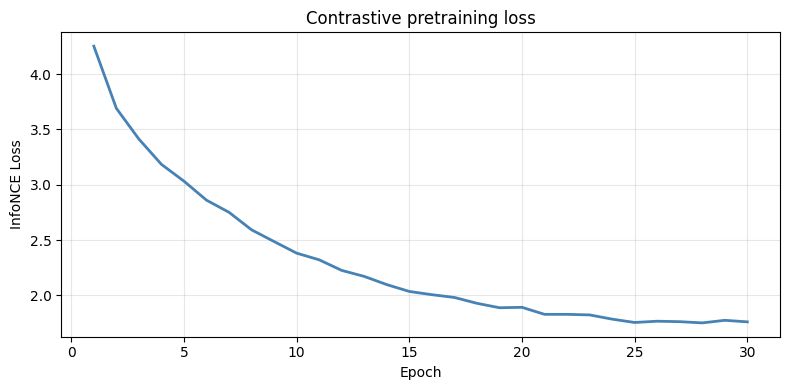

Loss curve saved


In [ ]:
import os

os.makedirs(f'{DRIVE_BASE}/checkpoints/contrastive', exist_ok=True)

# Save the full model state — we'll load encoders from this for fine-tuning
pretrain_ckpt_path = f'{DRIVE_BASE}/checkpoints/contrastive/pretrained_encoders.pt'
torch.save({
    'visual_encoder': {
        k[len('visual.'):]: v
        for k, v in model.state_dict().items()
        if k.startswith('visual.')
    },
    'pose_encoder': {
        k[len('pose.'):]: v
        for k, v in model.state_dict().items()
        if k.startswith('pose.')
    },
    'pretrain_epochs': PRETRAIN_EP,
    'best_loss': best_loss,
    'temperature': TEMPERATURE,
}, pretrain_ckpt_path)

print(f"Saved pretrained encoders to {pretrain_ckpt_path}")

# Plot pretraining loss curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(range(1, PRETRAIN_EP+1), pretrain_losses,
         color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.title('Contrastive pretraining loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('contrastive_pretrain_loss.png', dpi=150, bbox_inches='tight')
plt.show()
!cp contrastive_pretrain_loss.png {DRIVE_BASE}/logs/contrastive_pretrain_loss.png
print("Loss curve saved")

## Fine Tuning

In [ ]:
!ls -lh /content/drive/MyDrive/6.S985/opentouch/checkpoints/contrastive/

total 328M
-rw------- 1 root root 328M May 18 05:58 pretrained_encoders.pt


In [ ]:
import torch

DRIVE_BASE = '/content/drive/MyDrive/6.S985/opentouch'

orig = torch.load(
    f'{DRIVE_BASE}/checkpoints/contrastive/pretrained_encoders.pt',
    map_location='cpu',
    weights_only=False  # needed because checkpoint contains numpy scalars
)
print(orig.keys())

# Re-map from nested dict to flat state dict with correct prefixes
pretrain_state = {}
for k, v in orig['visual_encoder'].items():
    pretrain_state[f'visual.{k}'] = v
for k, v in orig['pose_encoder'].items():
    pretrain_state[f'pose.{k}'] = v

corrected_ckpt = {
    'state_dict': pretrain_state,
    'epoch': 0,
    'name': 'contrastive_pretrain',
    'model': 'OpenTouch-DINOv3-B16-Classify',
    'task': 'grip',
    'fusion_method': 'gated',
    'num_classes': 28,
}

corrected_path = f'{DRIVE_BASE}/checkpoints/contrastive/pretrained_encoders_v2.pt'
torch.save(corrected_ckpt, corrected_path)
print(f"Saved to {corrected_path}")
print(f"Sample keys: {list(pretrain_state.keys())[:5]}")
print(f"Total params: {len(pretrain_state)}")

dict_keys(['visual_encoder', 'pose_encoder', 'pretrain_epochs', 'best_loss', 'temperature'])
Saved to /content/drive/MyDrive/6.S985/opentouch/checkpoints/contrastive/pretrained_encoders_v2.pt
Sample keys: ['visual.model.embeddings.cls_token', 'visual.model.embeddings.mask_token', 'visual.model.embeddings.register_tokens', 'visual.model.embeddings.patch_embeddings.weight', 'visual.model.embeddings.patch_embeddings.bias']
Total params: 233


In [ ]:
# Load pretrained encoders into a fresh model and fine-tune
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip \
    --modalities visual pose \
    --fusion-method gated \
    --pretrained {DRIVE_BASE}/checkpoints/contrastive/pretrained_encoders.pt \
    --batch-size 64 \
    --lr 3e-3 \
    --epochs 60 \
    --report-to tensorboard \
    --name run6_contrastive_gated_60ep \
    --device cuda \
    --workers 4 \
    --save-frequency 60 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-05-18,05:58:16 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x7a02d6df2ec0>
└ # D2 [2 B]
2026-05-18,06:00:10 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x7a02d522c740>
└ # D2 [2 B]
2026-05-18,06:02:04 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-05-18,06:02:04 | INFO | Discovered num_classes from data: 28
2026-05-18,06:02:05 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--dinov3-vitb16-pretrain-lvd1689m/snapshots/5931719e67bbdb9737e363e781fb0c67687896bc/config.json
Model config DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 768,
  "image_

In [ ]:
# Reset classification_params.py to remove the duplicate
params_path = '/content/opentouch/src/opentouch_train/classification_params.py'
with open(params_path, 'r') as f:
    content = f.read()

# Count occurrences
count = content.count('--fusion-method')
print(f"Found {count} occurrences of --fusion-method")

if count > 1:
    # Remove all occurrences then add back exactly once
    block = '''    parser.add_argument(
        "--fusion-method",
        type=str,
        default="concat",
        choices=["concat", "gated"],
        help="Fusion method for combining modality embeddings.",
    )\n'''
    # Remove all instances
    while block in content:
        content = content.replace(block, '', 1)
    # Add back exactly once before --label-smoothing
    content = content.replace(
        '    parser.add_argument(\n        "--label-smoothing"',
        block + '    parser.add_argument(\n        "--label-smoothing"',
        1
    )
    with open(params_path, 'w') as f:
        f.write(content)
    print("Fixed — removed duplicate")

# Verify
count_after = content.count('--fusion-method')
print(f"Now has {count_after} occurrence(s)")

Found 2 occurrences of --fusion-method
Fixed — removed duplicate
Now has 1 occurrence(s)


In [ ]:
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip \
    --modalities visual pose \
    --fusion-method gated \
    --pretrained /content/drive/MyDrive/6.S985/opentouch/checkpoints/contrastive/pretrained_encoders_v2.pt \
    --batch-size 64 \
    --lr 3e-3 \
    --epochs 60 \
    --report-to tensorboard \
    --name run6_contrastive_gated_60ep_v2 \
    --device cuda \
    --workers 4 \
    --save-frequency 60 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-05-18,15:39:14 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x7db5259c2300>
└ # D2 [2 B]
2026-05-18,15:41:16 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x7db52245ff40>
└ # D2 [2 B]
2026-05-18,15:43:11 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-05-18,15:43:11 | INFO | Discovered num_classes from data: 28
2026-05-18,15:43:11 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
2026-05-18,15:43:12 | INFO | HTTP Request: GET https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
config.json: 100% 744/744 [00:00<00:00, 3.33MB/s]
2026-05-18,15:43:12 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
loading configuration file config.json from cache at /ro

### Evaluation

In [ ]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run6_contrastive_gated_60ep_v2/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda --batch-size 8 --workers 2 \
    --fusion-method gated

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['visual', 'pose']  Epoch: 60
Classification split 'test': 263 samples from 263 clips.
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100% 211/211 [00:00<00:00, 735.43it/s, Materializing param=norm.weight]
Loaded checkpoint from '/content/opentouch/logs/run6_contrastive_gated_60ep_v2/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run6_contrastive_gated_60ep_v2/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extens

In [ ]:
!cp -r /content/opentouch/logs/run6_contrastive_gated_60ep_v2 \
    {DRIVE_BASE}/logs/
print("Saved to Drive")

Saved to Drive


In [ ]:
!cp -r /content/opentouch/logs/run6_contrastive_gated_60ep_v2 \
    /content/drive/MyDrive/6.S985/opentouch/logs/
print("Saved")

Saved
